# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026

# EDA. Zenodo Solar Models

This notebook loads the downloaded SF3 solar-model tables from Zenodo, performs a preliminary exploratory analysis, compares the models, and exports each model using the same compact CSV schemas as the bundled B16 reference files:

- `fluxes_b16.csv`: `fraction,flux`
- `nudistr_b16_agss09.csv`: `radius,density_log_10,<source> fraction`


## 1. Libraries

This section imports the numerical, tabular, plotting, and notebook utilities used throughout the EDA.

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.util.notebooks import save_and_show

print(f"NumPy version : {np.__version__}")
print(f"Pandas version: {pd.__version__}")


NumPy version : 1.26.4
Pandas version: 2.3.3


## 2. Paths and Configuration

All input paths, output paths, model names, and conversion options are defined here.

### 2.1 Paths

The raw Zenodo files are read from `data/solar/zenodo`. Converted CSV files are written both to a local processed-data folder and to the notebook output directory.

In [2]:
config = load_notebook_config()

PACKAGE_DIR = config.package_dir
SOLAR_DATA_DIR = config.data_dir / "solar"
ZENODO_RAW_DIR = SOLAR_DATA_DIR / "zenodo"
ZENODO_PROCESSED_DIR = ZENODO_RAW_DIR / "processed"
OUTPUT_DIR = config.output_dir("external", "zenodo", "solar_models")

B16_FLUX_FILE = SOLAR_DATA_DIR / "fluxes_b16.csv"
B16_PROFILE_FILE = SOLAR_DATA_DIR / "nudistr_b16_agss09.csv"

ZENODO_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Raw Zenodo directory      :", ZENODO_RAW_DIR)
print("Processed data directory  :", ZENODO_PROCESSED_DIR)
print("Notebook output directory :", OUTPUT_DIR)
print("B16 flux reference        :", B16_FLUX_FILE)
print("B16 profile reference     :", B16_PROFILE_FILE)


Raw Zenodo directory      : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\zenodo
Processed data directory  : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\zenodo\processed
Notebook output directory : v:\output\external\zenodo\solar_models
B16 flux reference        : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\fluxes_b16.csv
B16 profile reference     : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\nudistr_b16_agss09.csv


### 2.2 Parameters and Configuration

The model identifiers are inferred from the file names. The compact output keeps the same neutrino sources and column order as the bundled B16 tables.

In [3]:
SOURCE_ORDER = ["13N", "15O", "17F", "7Be", "8B", "hep", "pep", "pp"]
ZENODO_PROFILE_SOURCE_COLUMNS = {
    "pp": "nu_pp",
    "pep": "nu_pep",
    "hep": "nu_hep",
    "7Be": "nu_7Be",
    "8B": "nu_8B",
    "13N": "nu_13N",
    "15O": "nu_15O",
    "17F": "nu_17F",
}
PROFILE_OUTPUT_COLUMNS = [
    "radius",
    "density_log_10",
    "pp fraction",
    "pep fraction",
    "hep fraction",
    "7Be fraction",
    "8B fraction",
    "13N fraction",
    "15O fraction",
    "17F fraction",
]

FLUX_FILE_PATTERN = "fluxes_SF3_*.dat"
PROFILE_FILE_PATTERN = "struct+nu_SF3_*.dat"
MODEL_NAME_PATTERN = re.compile(r"(?:fluxes|struct\+nu)_SF3_(?P<model>.+)\.dat$")

print("Sources exported:", SOURCE_ORDER)


Sources exported: ['13N', '15O', '17F', '7Be', '8B', 'hep', 'pep', 'pp']


## 3. Load Zenodo Solar Models

### 3.1 Column Description

The raw `struct+nu` files contain the solar structure and neutrino production profiles. For TPeanuts solar propagation, the compact exported profile keeps only:

- `radius`: radius fraction $r/R_\odot$.
- `density_log_10`: $\log_{10}(n_e / \mathrm{mol\,cm^{-3}})$ from the raw `log_ne` column.
- `<source> fraction`: radial production profile for each solar neutrino source, mapped from the raw `nu_<source>` columns.

The raw flux files contain one row of total fluxes and one row of fractional uncertainties. The compact exported flux table keeps only `fraction,flux`, matching `fluxes_b16.csv`.


In [4]:
def infer_model_name(path: Path) -> str:
    match = MODEL_NAME_PATTERN.match(path.name)
    if not match:
        raise ValueError(f"Cannot infer model name from {path.name!r}.")
    return match.group("model")


def read_zenodo_flux(path: Path) -> pd.DataFrame:
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    if len(lines) < 3:
        raise ValueError(f"Flux file is too short: {path}")
    sources = lines[1].split()
    fluxes = [float(value) for value in lines[2].split()[: len(sources)]]
    table = pd.DataFrame({"fraction": sources, "flux": fluxes})
    return table.set_index("fraction").loc[SOURCE_ORDER].reset_index()


def read_zenodo_profile_raw(path: Path) -> pd.DataFrame:
    header = path.read_text(encoding="utf-8", errors="replace").splitlines()[0].strip().lstrip("#").split()
    return pd.read_csv(path, sep=r"\s+", comment="#", names=header)


def convert_zenodo_profile(raw: pd.DataFrame) -> pd.DataFrame:
    raw = raw.loc[raw["R_sun"] > 0.0].reset_index(drop=True)
    converted = pd.DataFrame({"radius": raw["R_sun"], "density_log_10": raw["log_ne"]})
    for source, raw_column in ZENODO_PROFILE_SOURCE_COLUMNS.items():
        converted[f"{source} fraction"] = raw[raw_column]
    return converted.loc[:, PROFILE_OUTPUT_COLUMNS]


def load_zenodo_models(raw_dir: Path):
    flux_tables = {}
    raw_profiles = {}
    compact_profiles = {}
    for flux_path in sorted(raw_dir.glob(FLUX_FILE_PATTERN)):
        flux_tables[infer_model_name(flux_path)] = read_zenodo_flux(flux_path)
    for profile_path in sorted(raw_dir.glob(PROFILE_FILE_PATTERN)):
        model = infer_model_name(profile_path)
        raw_profile = read_zenodo_profile_raw(profile_path)
        raw_profiles[model] = raw_profile
        compact_profiles[model] = convert_zenodo_profile(raw_profile)
    if set(flux_tables) != set(compact_profiles):
        raise ValueError(f"Flux/profile model mismatch: flux={sorted(flux_tables)}, profiles={sorted(compact_profiles)}")
    return flux_tables, raw_profiles, compact_profiles


flux_tables, raw_profiles, compact_profiles = load_zenodo_models(ZENODO_RAW_DIR)
model_names = sorted(flux_tables)

print(f"Loaded {len(model_names)} Zenodo solar models:", model_names)
print("Rows per compact profile:")
for model in model_names:
    print(f"  {model:8s}: {len(compact_profiles[model]):5d}")


Loaded 6 Zenodo solar models: ['AAG21', 'AGSS09', 'C11', 'GS98', 'MB22m', 'MB22p']
Rows per compact profile:
  AAG21   :  2000
  AGSS09  :  2000
  C11     :  2000
  GS98    :  2000
  MB22m   :  2000
  MB22p   :  2000


### 3.2 First Inspection

The compact tables below are the exact schemas that will be exported.

In [5]:
print("Reference B16 flux schema:")
display(pd.read_csv(B16_FLUX_FILE).head())
print("Reference B16 profile schema:")
display(pd.read_csv(B16_PROFILE_FILE).head())

first_model = model_names[0]
print(f"Zenodo compact flux schema ({first_model}):")
display(flux_tables[first_model])
print(f"Zenodo compact profile schema ({first_model}):")
display(compact_profiles[first_model].head())


Reference B16 flux schema:


,fraction,flux
0,13N,2.040000e+08
1,15O,1.440000e+08
2,17F,3.260000e+06
3,7Be,4.500000e+09
4,8B,4.500000e+06


Reference B16 profile schema:


,radius,density_log_10,pp fraction,pep fraction,hep fraction,7Be fraction,8B fraction,13N fraction,15O fraction,17F fraction
0,0.0005,2.004,0.001036,0.001621,0.000440,0.005081,0.012601,0.007436,0.010562,0.011557
1,0.0010,2.004,0.002543,0.003980,0.001080,0.012475,0.030935,0.018250,0.025925,0.028365
2,0.0015,2.004,0.006322,0.009894,0.002686,0.031008,0.076875,0.045365,0.064441,0.070509
3,0.0020,2.004,0.010422,0.016308,0.004429,0.051096,0.126622,0.074753,0.106186,0.116192
4,0.0025,2.004,0.015544,0.024320,0.006607,0.076174,0.188672,0.111414,0.158263,0.173178


Zenodo compact flux schema (AAG21):


,fraction,flux
0,13N,2.221000e+08
1,15O,1.577000e+08
2,17F,3.401000e+06
3,7Be,4.517000e+09
4,8B,4.309000e+06
5,hep,8.161000e+03
6,pep,1.447000e+08
7,pp,6.000000e+10


Zenodo compact profile schema (AAG21):


,radius,density_log_10,pp fraction,pep fraction,hep fraction,7Be fraction,8B fraction,13N fraction,15O fraction,17F fraction
0,0.0005,2.00350,0.000680,0.001066,0.000288,0.003347,0.008344,0.004959,0.006994,0.007657
1,0.0010,2.00349,0.002060,0.003228,0.000873,0.010141,0.025250,0.015020,0.021183,0.023214
2,0.0015,2.00347,0.004615,0.007232,0.001955,0.022714,0.056533,0.033647,0.047453,0.052012
3,0.0020,2.00343,0.008203,0.012853,0.003476,0.040360,0.100411,0.059779,0.084309,0.092411
4,0.0025,2.00338,0.012816,0.020078,0.005431,0.063025,0.156719,0.093319,0.131611,0.144259


## 4. EDA: Structure and Sanity Checks

In [6]:
profile_summary_rows = []
for model, table in compact_profiles.items():
    source_integrals = {
        column.replace(" fraction", "_integral"): np.trapz(table[column], x=table["radius"])
        for column in table.columns
        if column.endswith(" fraction")
    }
    profile_summary_rows.append(
        {
            "model": model,
            "rows": len(table),
            "radius_min": table["radius"].min(),
            "radius_max": table["radius"].max(),
            "core_log10_ne": table["density_log_10"].iloc[0],
            "edge_log10_ne": table["density_log_10"].iloc[-1],
            **source_integrals,
        }
    )
profile_summary = pd.DataFrame(profile_summary_rows).set_index("model").sort_index()
display(profile_summary)

flux_summary = pd.concat(
    [table.assign(model=model) for model, table in flux_tables.items()],
    ignore_index=True,
).pivot(index="fraction", columns="model", values="flux").loc[SOURCE_ORDER]
display(flux_summary)


,rows,radius_min,radius_max,core_log10_ne,edge_log10_ne,pp_integral,pep_integral,hep_integral,7Be_integral,8B_integral,13N_integral,15O_integral,17F_integral
model,,,,,,,,,,,,,
AAG21,2000,0.0005,1.0,2.00350,-10.6320,1.0,1.0,1.0,0.999999,0.999998,0.999999,0.999998,0.999998
AGSS09,2000,0.0005,1.0,2.00309,-10.6285,1.0,1.0,1.0,0.999999,0.999998,0.999999,0.999999,0.999998
C11,2000,0.0005,1.0,2.00375,-10.6400,1.0,1.0,1.0,0.999999,0.999998,0.999999,0.999998,0.999998
GS98,2000,0.0005,1.0,2.00354,-10.6281,1.0,1.0,1.0,0.999999,0.999998,0.999999,0.999998,0.999998
MB22m,2000,0.0005,1.0,2.00341,-10.6203,1.0,1.0,1.0,0.999999,0.999998,0.999999,0.999998,0.999998
MB22p,2000,0.0005,1.0,2.00328,-10.6221,1.0,1.0,1.0,0.999999,0.999998,0.999999,0.999998,0.999998


model,AAG21,AGSS09,C11,GS98,MB22m,MB22p
fraction,,,,,,
13N,2.221000e+08,2.052000e+08,2.480000e+08,2.795000e+08,3.118000e+08,3.102000e+08
15O,1.577000e+08,1.447000e+08,1.776000e+08,2.067000e+08,2.322000e+08,2.304000e+08
17F,3.401000e+06,3.290000e+06,4.136000e+06,5.350000e+06,4.738000e+06,4.699000e+06
7Be,4.517000e+09,4.429000e+09,4.603000e+09,4.854000e+09,4.899000e+09,4.875000e+09
8B,4.309000e+06,4.135000e+06,4.484000e+06,5.025000e+06,5.127000e+06,5.074000e+06
hep,8.161000e+03,8.216000e+03,8.098000e+03,7.950000e+03,7.922000e+03,7.934000e+03
pep,1.447000e+08,1.451000e+08,1.441000e+08,1.425000e+08,1.422000e+08,1.422000e+08
pp,6.000000e+10,6.010000e+10,5.990000e+10,5.960000e+10,5.950000e+10,5.950000e+10


## 5. Model Comparisons

### 5.1 Flux Comparison

The first panel compares absolute total fluxes. The second panel shows relative differences with respect to the `AGSS09` model when available.

Saved figure: v:\output\external\zenodo\solar_models\zenodo_solar_flux_comparison.png


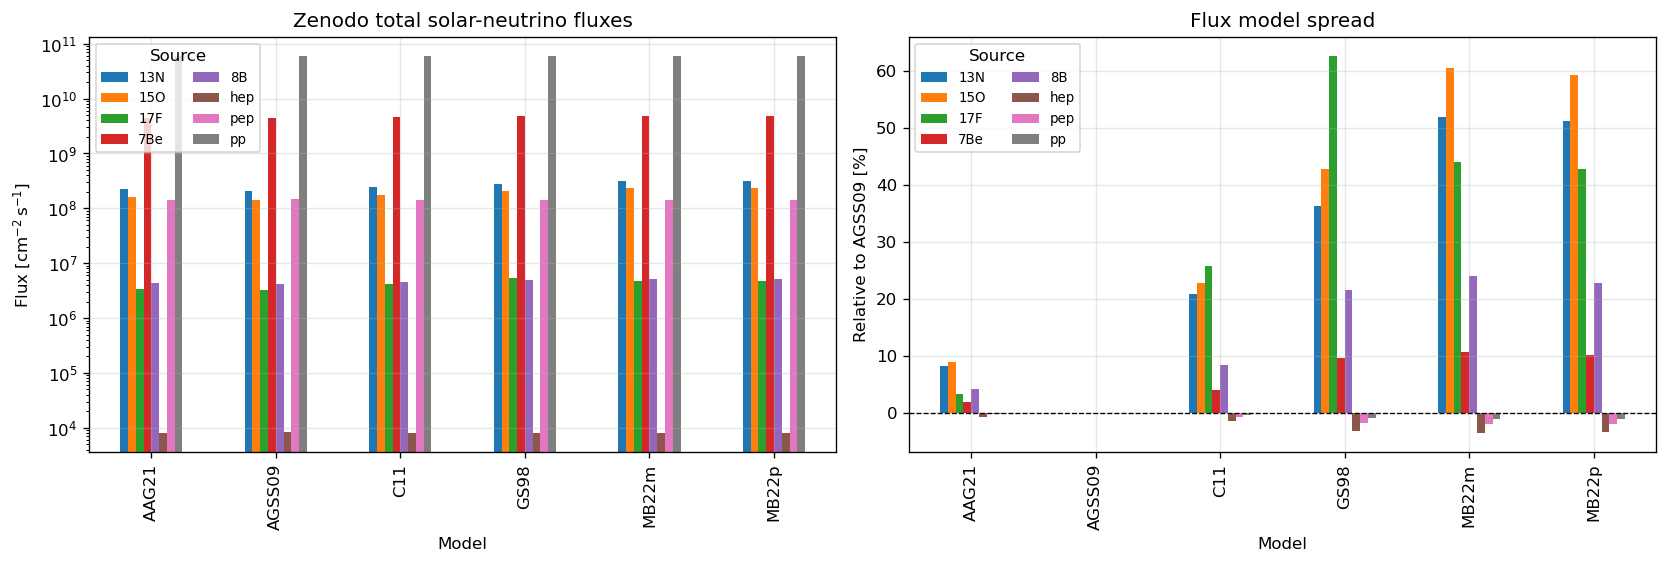

WindowsPath('v:/output/external/zenodo/solar_models/zenodo_solar_flux_comparison.png')

In [7]:
reference_model = "AGSS09" if "AGSS09" in flux_summary.columns else model_names[0]
relative_flux = (flux_summary.divide(flux_summary[reference_model], axis=0) - 1.0) * 100.0

fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.8))
flux_summary.T.plot(kind="bar", ax=axes[0], logy=True)
axes[0].set_xlabel("Model")
axes[0].set_ylabel(r"Flux [$\mathrm{cm^{-2}\,s^{-1}}$]")
axes[0].set_title("Zenodo total solar-neutrino fluxes")
axes[0].legend(title="Source", fontsize=8, ncols=2)

relative_flux.T.plot(kind="bar", ax=axes[1])
axes[1].axhline(0.0, color="black", lw=0.8, ls="--")
axes[1].set_xlabel("Model")
axes[1].set_ylabel(f"Relative to {reference_model} [%]")
axes[1].set_title("Flux model spread")
axes[1].legend(title="Source", fontsize=8, ncols=2)
fig.tight_layout()
save_and_show("zenodo_solar_flux_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


### 5.2 Density Profile Comparison

The `log_ne` column is used directly as the exported `density_log_10`, matching the B16 profile convention.

Saved figure: v:\output\external\zenodo\solar_models\zenodo_solar_density_comparison.png


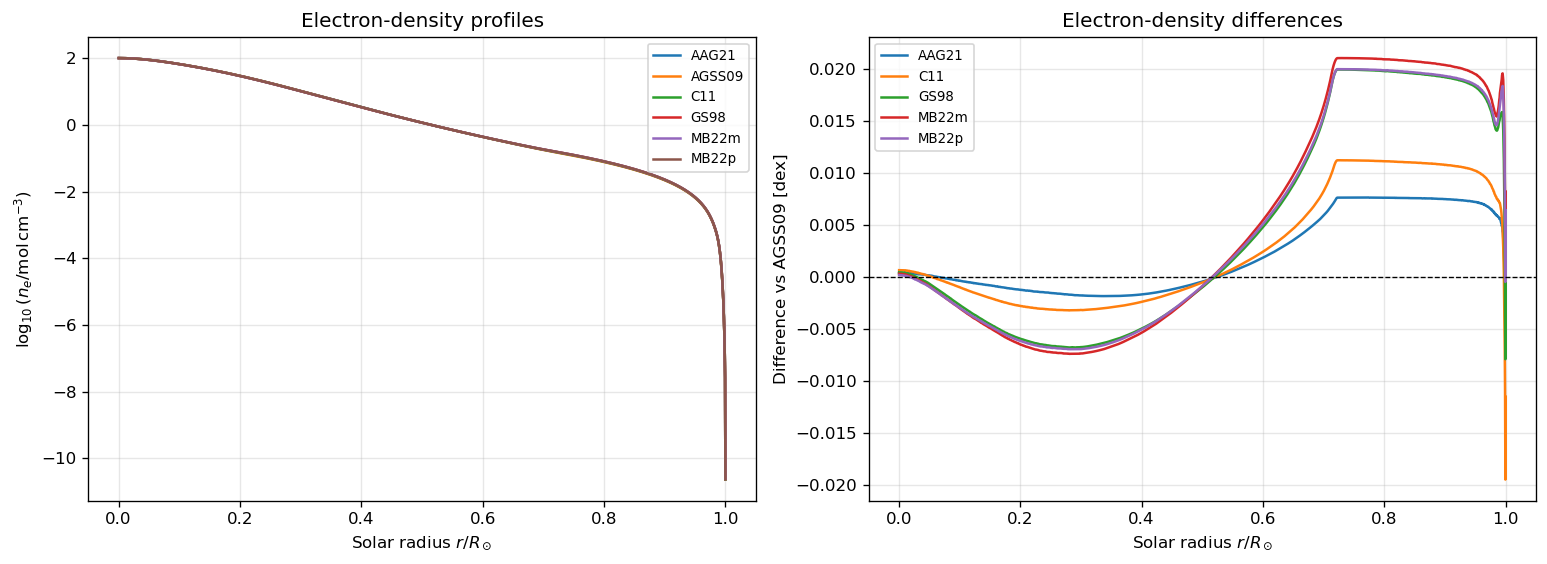

WindowsPath('v:/output/external/zenodo/solar_models/zenodo_solar_density_comparison.png')

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
for model, table in compact_profiles.items():
    axes[0].plot(table["radius"], table["density_log_10"], label=model)
axes[0].set_xlabel(r"Solar radius $r/R_\odot$")
axes[0].set_ylabel(r"$\log_{10}(n_e / \mathrm{mol\,cm^{-3}})$")
axes[0].set_title("Electron-density profiles")
axes[0].legend(fontsize=8)

reference_density = compact_profiles[reference_model].set_index("radius")["density_log_10"]
for model, table in compact_profiles.items():
    if model == reference_model:
        continue
    aligned = table.set_index("radius")["density_log_10"] - reference_density
    axes[1].plot(aligned.index, aligned.values, label=model)
axes[1].axhline(0.0, color="black", lw=0.8, ls="--")
axes[1].set_xlabel(r"Solar radius $r/R_\odot$")
axes[1].set_ylabel(f"Difference vs {reference_model} [dex]")
axes[1].set_title("Electron-density differences")
axes[1].legend(fontsize=8)
fig.tight_layout()
save_and_show("zenodo_solar_density_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


### 5.3 Neutrino Production Profile Comparison

These profiles are the radial source distributions exported as `<source> fraction` columns.

Saved figure: v:\output\external\zenodo\solar_models\zenodo_solar_production_profiles.png


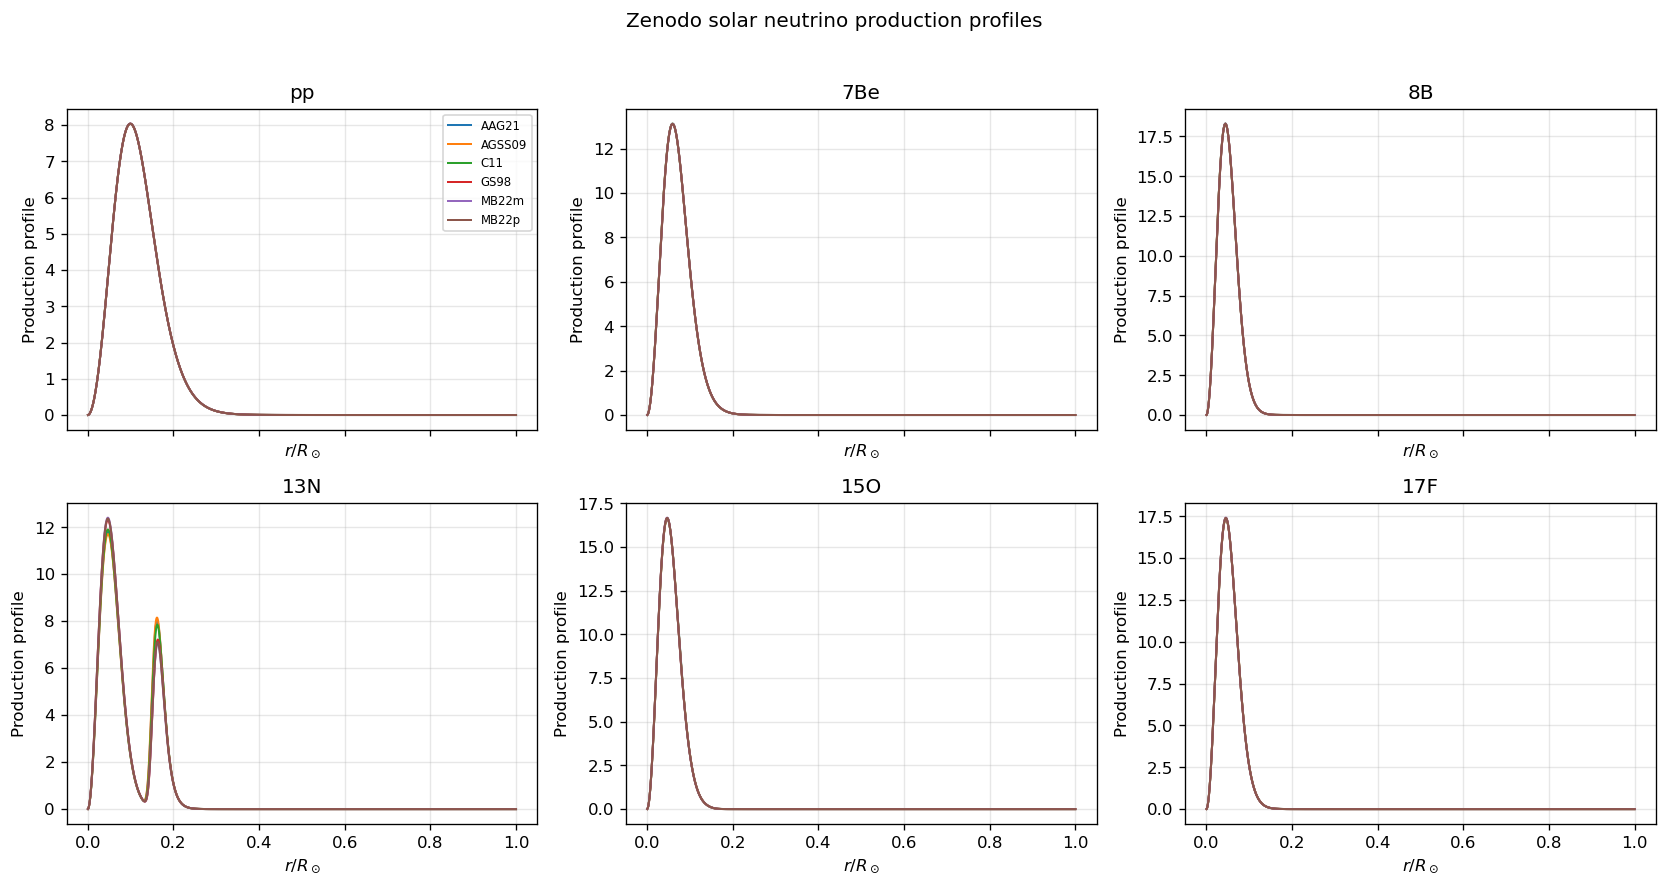

WindowsPath('v:/output/external/zenodo/solar_models/zenodo_solar_production_profiles.png')

In [9]:
plot_sources = ["pp", "7Be", "8B", "13N", "15O", "17F"]
fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.2), sharex=True)
axes = axes.ravel()
for ax, source in zip(axes, plot_sources):
    column = f"{source} fraction"
    for model, table in compact_profiles.items():
        ax.plot(table["radius"], table[column], label=model, lw=1.2)
    ax.set_title(source)
    ax.set_xlabel(r"$r/R_\odot$")
    ax.set_ylabel("Production profile")
axes[0].legend(fontsize=7)
fig.suptitle("Zenodo solar neutrino production profiles", y=1.02)
fig.tight_layout()
save_and_show("zenodo_solar_production_profiles.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 6. Export Compact CSV Files

The exported CSV files intentionally use the same headers as the B16 reference files, so they can be passed to the existing solar-profile loader with minimal additional wiring.

In [10]:
export_rows = []
for model in model_names:
    flux_output_name = f"fluxes_zenodo_SF3_{model}.csv"
    profile_output_name = f"nudistr_zenodo_SF3_{model}.csv"
    flux_table = flux_tables[model].loc[:, ["fraction", "flux"]]
    profile_table = compact_profiles[model].loc[:, PROFILE_OUTPUT_COLUMNS]
    for output_root in [ZENODO_PROCESSED_DIR, OUTPUT_DIR]:
        flux_path = output_root / flux_output_name
        profile_path = output_root / profile_output_name
        flux_table.to_csv(flux_path, index=False)
        profile_table.to_csv(profile_path, index=False)
        export_rows.append(
            {
                "model": model,
                "output_root": output_root,
                "flux_file": flux_path,
                "profile_file": profile_path,
                "flux_rows": len(flux_table),
                "profile_rows": len(profile_table),
            }
        )
exports = pd.DataFrame(export_rows)
display(exports)


,model,output_root,flux_file,profile_file,flux_rows,profile_rows
0,AAG21,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,8,2000
1,AAG21,v:\output\external\zenodo\solar_models,v:\output\external\zenodo\solar_models\fluxes_...,v:\output\external\zenodo\solar_models\nudistr...,8,2000
2,AGSS09,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,8,2000
3,AGSS09,v:\output\external\zenodo\solar_models,v:\output\external\zenodo\solar_models\fluxes_...,v:\output\external\zenodo\solar_models\nudistr...,8,2000
4,C11,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,8,2000
5,C11,v:\output\external\zenodo\solar_models,v:\output\external\zenodo\solar_models\fluxes_...,v:\output\external\zenodo\solar_models\nudistr...,8,2000
6,GS98,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,8,2000
7,GS98,v:\output\external\zenodo\solar_models,v:\output\external\zenodo\solar_models\fluxes_...,v:\output\external\zenodo\solar_models\nudistr...,8,2000
8,MB22m,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\dat...,8,2000
9,MB22m,v:\output\external\zenodo\solar_models,v:\output\external\zenodo\solar_models\fluxes_...,v:\output\external\zenodo\solar_models\nudistr...,8,2000


## 7. Export Verification

In [11]:
b16_flux_columns = list(pd.read_csv(B16_FLUX_FILE, nrows=0).columns)
b16_profile_columns = list(pd.read_csv(B16_PROFILE_FILE, nrows=0).columns)
verification_rows = []
for model in model_names:
    flux_path = ZENODO_PROCESSED_DIR / f"fluxes_zenodo_SF3_{model}.csv"
    profile_path = ZENODO_PROCESSED_DIR / f"nudistr_zenodo_SF3_{model}.csv"
    flux_read = pd.read_csv(flux_path)
    profile_read = pd.read_csv(profile_path)
    verification_rows.append(
        {
            "model": model,
            "flux_schema_ok": list(flux_read.columns) == b16_flux_columns,
            "profile_schema_ok": list(profile_read.columns) == b16_profile_columns,
            "flux_sources_ok": flux_read["fraction"].tolist() == SOURCE_ORDER,
            "profile_radius_monotonic": profile_read["radius"].is_monotonic_increasing,
            "profile_finite": np.isfinite(profile_read.to_numpy(dtype=float)).all(),
        }
    )
verification = pd.DataFrame(verification_rows).set_index("model")
display(verification)
if not verification.all(axis=None):
    raise RuntimeError("At least one exported Zenodo solar table failed verification.")
print("All exported Zenodo solar tables match the compact B16 schemas.")


,flux_schema_ok,profile_schema_ok,flux_sources_ok,profile_radius_monotonic,profile_finite
model,,,,,
AAG21,True,True,True,True,True
AGSS09,True,True,True,True,True
C11,True,True,True,True,True
GS98,True,True,True,True,True
MB22m,True,True,True,True,True
MB22p,True,True,True,True,True


All exported Zenodo solar tables match the compact B16 schemas.


## 8. Summary

In [12]:
print("Zenodo solar-model EDA summary")
print("-" * 72)
print(f"Models processed       : {', '.join(model_names)}")
print(f"Flux output schema     : {b16_flux_columns}")
print(f"Profile output schema  : {b16_profile_columns}")
print(f"Processed data folder  : {ZENODO_PROCESSED_DIR}")
print(f"Notebook output folder : {OUTPUT_DIR}")


Zenodo solar-model EDA summary
------------------------------------------------------------------------
Models processed       : AAG21, AGSS09, C11, GS98, MB22m, MB22p
Flux output schema     : ['fraction', 'flux']
Profile output schema  : ['radius', 'density_log_10', 'pp fraction', 'pep fraction', 'hep fraction', '7Be fraction', '8B fraction', '13N fraction', '15O fraction', '17F fraction']
Processed data folder  : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar\zenodo\processed
Notebook output folder : v:\output\external\zenodo\solar_models
